# *****Anomaly Detection Model*****

| Feature | Simbol | Deskripsi |
|---|---|---|
| avg_time_per_cell | `tpc` | detik per sel yang dikerjakan pemain |
| error_rate | `er` | proporsi moves yang salah |
| hint_rate | `hr` | proporsi hint terhadap moves |
| completion_rate | `cr` | 1.0 = selesai, 0.0 = tidak selesai |
| near_miss_rate | `nmr` | rasio hampir-benar terhadap total error |
| guessing_rate | `gur` | rasio asal-tebak terhadap total error |

In [1]:
import numpy as np
import pandas as pd
import pickle, warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, ParameterGrid, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    f1_score, classification_report, confusion_matrix
)
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
np.random.seed(42)

FEATURE_NAMES = [
    'avg_time_per_cell', 'error_rate', 'hint_rate',
    'completion_rate', 'near_miss_rate', 'guessing_rate'
]

## 1. ***Generate* Data Sintetis**

Data dibuat dari distribusi per tipe pemain (normal) dan pola tidak wajar (anomali). Label hanya dipakai untuk evaluasi dan *tuning threshold*. IsolationForest sendiri bersifat unsupervised.

In [2]:
rng = np.random.default_rng(42)

def clip(arr, lo=0.0, hi=1.0):
    return np.clip(arr, lo, hi)

# NORMAL SESSIONS (label = 0)

def gen_speedrunner(n, rng):
    tpc = clip(rng.normal(2.5,  0.8,  n), 0.5, 6.0)
    er  = clip(rng.normal(0.03, 0.02, n), 0.0, 0.12)
    hr  = clip(rng.normal(0.02, 0.01, n), 0.0, 0.08)
    cr  = clip(rng.normal(0.97, 0.04, n), 0.7, 1.0)
    nmr = clip(rng.normal(0.35, 0.15, n), 0.0, 0.8)
    gur = clip(rng.normal(0.08, 0.06, n), 0.0, 0.4)
    return np.column_stack([tpc, er, hr, cr, nmr, gur])

def gen_careful(n, rng):
    tpc = clip(rng.normal(20.0, 4.0,  n), 10.0, 35.0)
    er  = clip(rng.normal(0.04, 0.02, n), 0.0,  0.12)
    hr  = clip(rng.normal(0.04, 0.02, n), 0.0,  0.12)
    cr  = clip(rng.normal(0.95, 0.05, n), 0.7,  1.0)
    nmr = clip(rng.normal(0.55, 0.15, n), 0.1,  0.9)
    gur = clip(rng.normal(0.07, 0.05, n), 0.0,  0.35)
    return np.column_stack([tpc, er, hr, cr, nmr, gur])

def gen_learner(n, rng):
    tpc = clip(rng.normal(9.0,  2.5,  n), 4.0,  18.0)
    er  = clip(rng.normal(0.15, 0.06, n), 0.04, 0.35)
    hr  = clip(rng.normal(0.18, 0.07, n), 0.04, 0.40)
    cr  = clip(rng.normal(0.70, 0.12, n), 0.35, 0.95)
    nmr = clip(rng.normal(0.50, 0.18, n), 0.0,  0.9)
    gur = clip(rng.normal(0.28, 0.12, n), 0.0,  0.65)
    return np.column_stack([tpc, er, hr, cr, nmr, gur])

def gen_struggling(n, rng):
    tpc = clip(rng.normal(22.0, 6.0,  n), 8.0,  45.0)
    er  = clip(rng.normal(0.42, 0.10, n), 0.20, 0.70)
    hr  = clip(rng.normal(0.50, 0.12, n), 0.20, 0.80)
    cr  = clip(rng.normal(0.28, 0.14, n), 0.0,  0.65)
    nmr = clip(rng.normal(0.38, 0.18, n), 0.0,  0.8)
    gur = clip(rng.normal(0.78, 0.12, n), 0.40, 1.0)
    return np.column_stack([tpc, er, hr, cr, nmr, gur])

def gen_inconsistent(n, rng):
    tpc = clip(rng.uniform(3.0, 28.0, n))
    er  = clip(rng.uniform(0.0,  0.5,  n))
    hr  = clip(rng.uniform(0.0,  0.5,  n))
    cr  = clip(rng.uniform(0.2,  1.0,  n))
    nmr = clip(rng.uniform(0.0,  0.9,  n))
    gur = clip(rng.uniform(0.0,  0.8,  n))
    return np.column_stack([tpc, er, hr, cr, nmr, gur])

# ANOMALOUS SESSIONS (label = 1)

def gen_cheat_speed(n, rng):
    """Selesai sangat cepat, nol error."""
    tpc = clip(rng.normal(0.3, 0.1, n), 0.05, 0.8)
    er  = clip(rng.normal(0.0, 0.005, n), 0.0, 0.02)
    hr  = clip(rng.normal(0.0, 0.005, n), 0.0, 0.02)
    cr  = np.ones(n)
    nmr = np.zeros(n)
    gur = np.zeros(n)
    return np.column_stack([tpc, er, hr, cr, nmr, gur])

def gen_hint_abuse(n, rng):
    """Hint dipakai hampir setiap langkah."""
    tpc = clip(rng.normal(5.0, 2.0, n), 1.0, 15.0)
    er  = clip(rng.normal(0.05, 0.03, n), 0.0, 0.15)
    hr  = clip(rng.normal(0.90, 0.06, n), 0.70, 1.0)
    cr  = clip(rng.normal(0.92, 0.06, n), 0.70, 1.0)
    nmr = clip(rng.normal(0.10, 0.08, n), 0.0, 0.4)
    gur = clip(rng.normal(0.05, 0.04, n), 0.0, 0.2)
    return np.column_stack([tpc, er, hr, cr, nmr, gur])

def gen_impossible_combo(n, rng):
    """Error sangat tinggi DAN selesai."""
    tpc = clip(rng.normal(10.0, 3.0, n), 3.0, 20.0)
    er  = clip(rng.normal(0.75, 0.10, n), 0.55, 1.0)
    hr  = clip(rng.normal(0.10, 0.05, n), 0.0,  0.3)
    cr  = np.ones(n)
    nmr = clip(rng.normal(0.20, 0.10, n), 0.0, 0.5)
    gur = clip(rng.normal(0.80, 0.10, n), 0.50, 1.0)
    return np.column_stack([tpc, er, hr, cr, nmr, gur])

def gen_idle_session(n, rng):
    """AFK panjang tanpa progres berarti."""
    tpc = clip(rng.normal(120.0, 30.0, n), 60.0, 250.0)
    er  = clip(rng.normal(0.02,  0.01, n), 0.0,  0.1)
    hr  = clip(rng.normal(0.02,  0.01, n), 0.0,  0.1)
    cr  = clip(rng.normal(0.10,  0.08, n), 0.0,  0.4)
    nmr = clip(rng.normal(0.05,  0.04, n), 0.0,  0.3)
    gur = clip(rng.normal(0.02,  0.02, n), 0.0,  0.1)
    return np.column_stack([tpc, er, hr, cr, nmr, gur])

def gen_corrupted(n, rng):
    """Data rusak: nilai yang saling bertentangan secara acak."""
    pool = np.concatenate([
        rng.uniform(0.0,  0.3,   n // 2),
        rng.uniform(80.0, 200.0, n - n // 2)
    ])
    tpc = rng.choice(pool, size=n, replace=True)
    er  = rng.uniform(0.0, 1.0, n)
    hr  = rng.uniform(0.0, 1.0, n)
    cr  = rng.choice(np.array([0.0, 1.0]), size=n, replace=True)
    nmr = rng.uniform(0.0, 1.0, n)
    gur = rng.uniform(0.0, 1.0, n)
    return np.column_stack([tpc, er, hr, cr, nmr, gur])

# Assemble
N_NORMAL = 1600
N_ANOM   = 400

X_normal = np.vstack([
    gen_speedrunner (N_NORMAL // 5, rng),
    gen_careful     (N_NORMAL // 5, rng),
    gen_learner     (N_NORMAL // 5, rng),
    gen_struggling  (N_NORMAL // 5, rng),
    gen_inconsistent(N_NORMAL // 5, rng),
])
X_anom = np.vstack([
    gen_cheat_speed     (N_ANOM // 5, rng),
    gen_hint_abuse      (N_ANOM // 5, rng),
    gen_impossible_combo(N_ANOM // 5, rng),
    gen_idle_session    (N_ANOM // 5, rng),
    gen_corrupted       (N_ANOM // 5, rng),
])

X_all = np.vstack([X_normal, X_anom])
y_all = np.array([0]*len(X_normal) + [1]*len(X_anom))

df = pd.DataFrame(X_all, columns=FEATURE_NAMES)
df['label'] = y_all

print(f'Dataset: {len(X_all)} baris | Normal: {len(X_normal)} | Anomali: {len(X_anom)}')
print(f'True contamination: {len(X_anom)/len(X_all)*100:.1f}%')
df.groupby('label')[FEATURE_NAMES].agg(['mean','std']).round(3)

Dataset: 2000 baris | Normal: 1600 | Anomali: 400
True contamination: 20.0%


avg_time_per_cell         error_rate        hint_rate         \
                   mean     std       mean    std      mean    std   
label                                                                
0                10.951   9.474      0.182  0.171     0.198  0.195   
1                41.269  57.491      0.259  0.328     0.311  0.369   

      completion_rate        near_miss_rate        guessing_rate         
                 mean    std           mean    std          mean    std  
label                                                                    
0               0.696  0.285          0.451  0.200         0.320  0.288  
1               0.704  0.416          0.171  0.219         0.271  0.350

## 2. ***Exploratory Data Analysis* (EDA)**

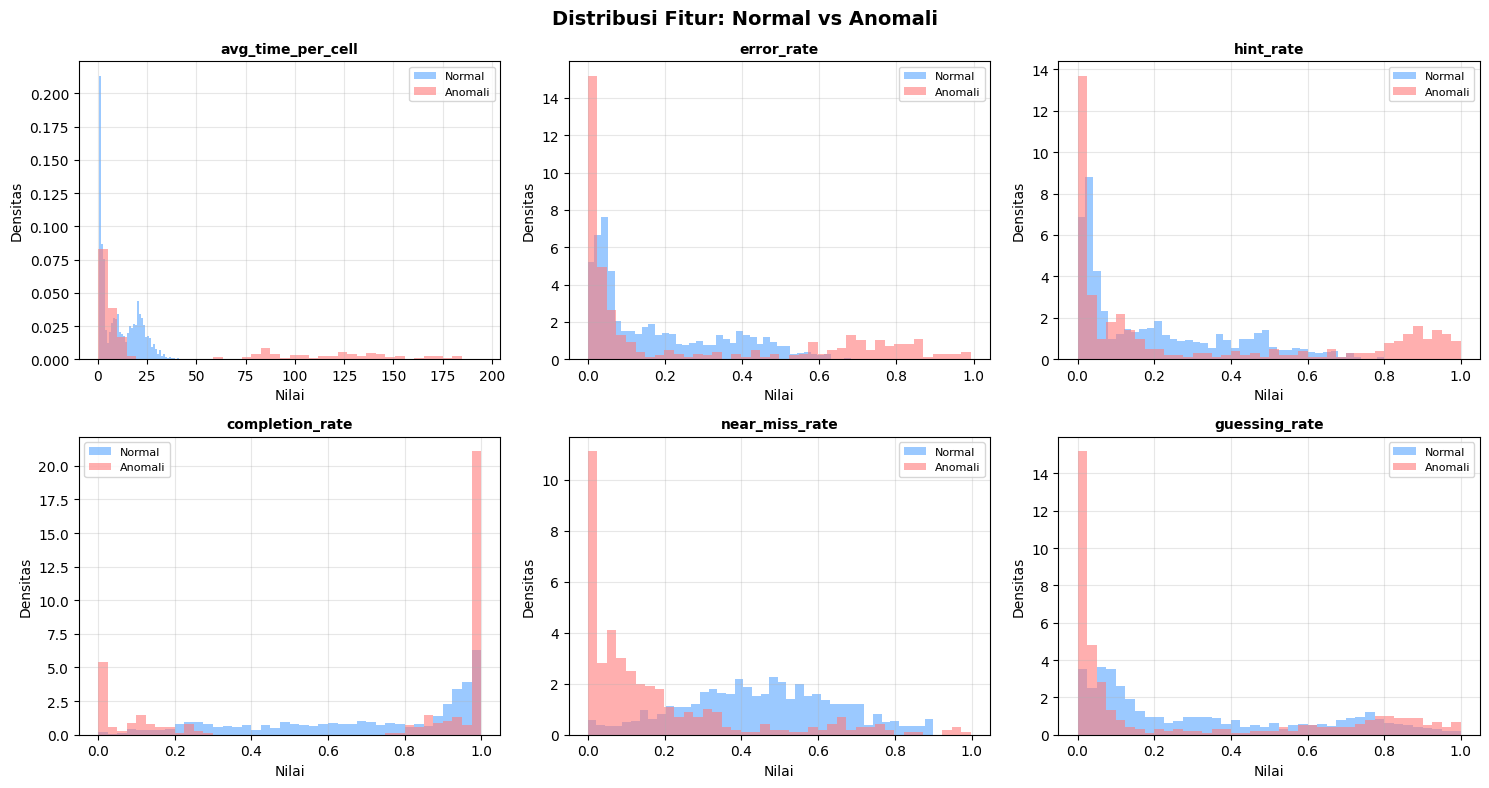

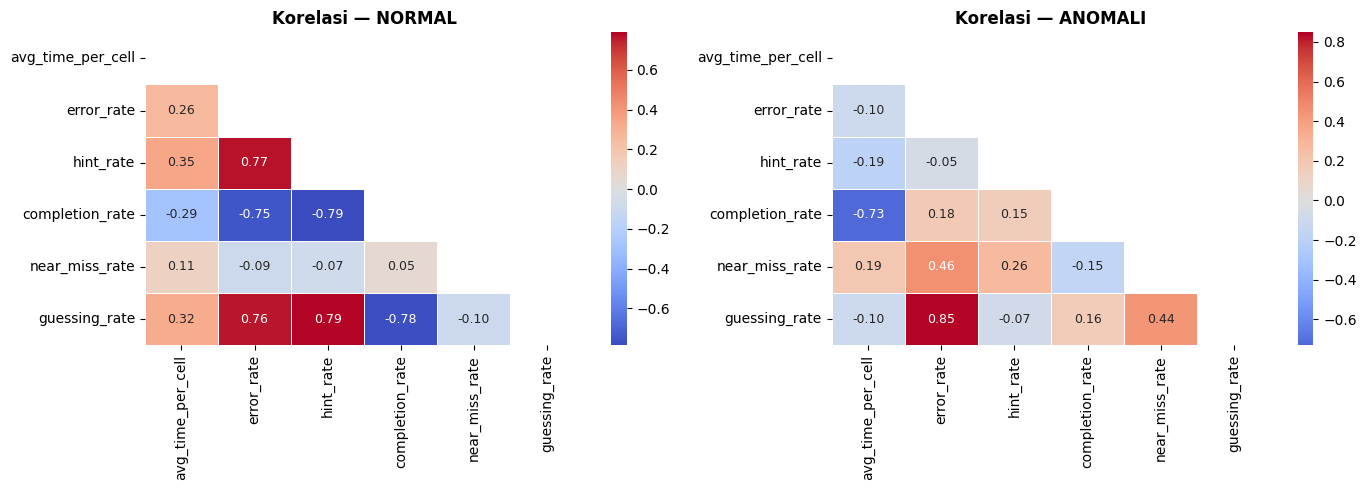

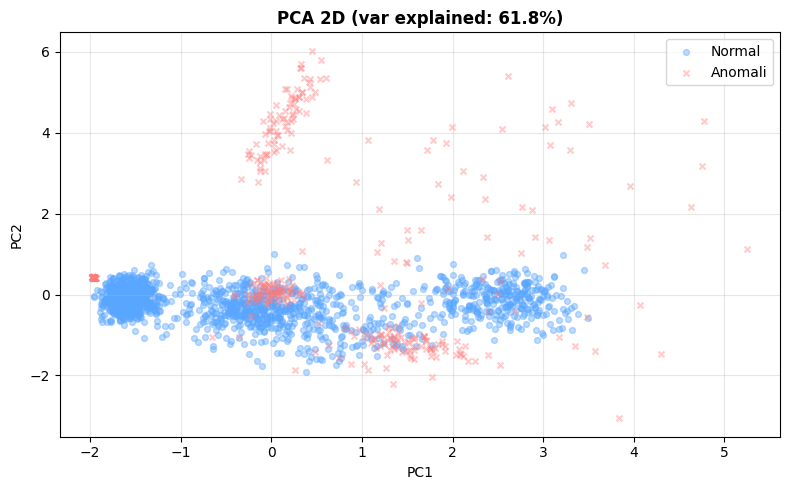

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribusi Fitur: Normal vs Anomali', fontsize=14, fontweight='bold')
pal = {0: '#58A6FF', 1: '#FF7B7B'}
labs = {0: 'Normal', 1: 'Anomali'}
for ax, feat in zip(axes.flat, FEATURE_NAMES):
    for lbl in [0, 1]:
        ax.hist(df[df['label']==lbl][feat], bins=40, alpha=0.6,
                color=pal[lbl], label=labs[lbl], density=True)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Nilai'); ax.set_ylabel('Densitas')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Korelasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, lbl, title in [(ax1,0,'Korelasi — NORMAL'),(ax2,1,'Korelasi — ANOMALI')]:
    corr = df[df['label']==lbl][FEATURE_NAMES].corr()
    sns.heatmap(corr, mask=np.triu(np.ones_like(corr,dtype=bool)),
                annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, annot_kws={'size':9}, linewidths=0.5)
    ax.set_title(title, fontweight='bold')
plt.tight_layout(); plt.show()

# PCA 2D
sc_eda = StandardScaler()
X_eda  = sc_eda.fit_transform(X_all)
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_eda)
fig, ax = plt.subplots(figsize=(8,5))
for lbl, col, mk in [(0,'#58A6FF','o'),(1,'#FF7B7B','x')]:
    m = y_all==lbl
    ax.scatter(X_pca[m,0], X_pca[m,1], c=col, marker=mk, alpha=0.4, s=18, label=labs[lbl])
ax.set_title(f'PCA 2D (var explained: {pca.explained_variance_ratio_.sum()*100:.1f}%)', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. ***Train/Validation/Test Split***

Data dibagi tiga agar *threshold tuning* menggunakan *validation set* yang tidak menyentuh test set.
- **Train (60%)** : hanya data normal, untuk melatih *Isolation Forest*
- **Validation (20%)** : berlabel, untuk mencari *threshold* optimal via F1
- **Test (20%)** : berlabel, evaluasi akhir yang jujur

Memisahkan validation dan test mencegah *threshold overfitting* ke satu set data.

In [4]:
# Split stratified: 60% train, 20% val, 20% test
X_tr_full, X_te, y_tr_full, y_te = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr_full, y_tr_full, test_size=0.25, stratify=y_tr_full, random_state=42)
# 0.25 dari 80% = 20% keseluruhan

# Scaler difit HANYA pada data normal di training set
X_tr_normal = X_tr[y_tr == 0]
scaler_final = StandardScaler()
scaler_final.fit(X_tr_normal)

X_tr_normal_sc = scaler_final.transform(X_tr_normal)
X_val_sc       = scaler_final.transform(X_val)
X_te_sc        = scaler_final.transform(X_te)
X_all_sc       = scaler_final.transform(X_all)

print(f'Train normal  : {len(X_tr_normal)} sampel')
print(f'Validation    : {len(X_val)} sampel  (normal:{(y_val==0).sum()}, anomali:{(y_val==1).sum()})')
print(f'Test          : {len(X_te)} sampel   (normal:{(y_te==0).sum()}, anomali:{(y_te==1).sum()})')

Train normal  : 960 sampel
Validation    : 400 sampel  (normal:320, anomali:80)
Test          : 400 sampel   (normal:320, anomali:80)


## 4. ***Hyperparameter Tuning***

**Kunci perbaikan:** `contamination` di grid tuning diturunkan ke 0.05–0.10.

Alasan: karena training hanya pada data normal, parameter `contamination` di IsolationForest hanya menentukan berapa persen data latih yang dianggap sebagai *outlier saat menetapkan offset score*. Setting 0.20 pada data normal murni menyebabkan 320 sesi normal terpotong sebagai anomali (*threshold* bergeser terlalu kanan). *Decision boundary* yang sesungguhnya akan dioptimalkan melalui F1 di langkah berikutnya.

In [5]:
param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_samples':   ['auto', 128, 256],
    'max_features':  [0.7, 1.0],
    'contamination': [0.05, 0.08, 0.10]   # rendah — hanya untuk offset score
}

skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for params in ParameterGrid(param_grid):
    fold_aucs, fold_aps = [], []

    for tr_idx, vl_idx in skf.split(X_all_sc, y_all):
        # Training hanya pakai data normal dari fold train
        X_fold_tr = X_all_sc[tr_idx][y_all[tr_idx] == 0]
        X_fold_vl = X_all_sc[vl_idx]
        y_fold_vl = y_all[vl_idx]

        iso = IsolationForest(**params, random_state=42, n_jobs=-1)
        iso.fit(X_fold_tr)

        scores = -iso.decision_function(X_fold_vl)
        fold_aucs.append(roc_auc_score(y_fold_vl, scores))
        fold_aps.append(average_precision_score(y_fold_vl, scores))

    mean_auc = np.mean(fold_aucs)
    std_auc  = np.std(fold_aucs)
    mean_ap  = np.mean(fold_aps)
    # Stability: penalti variance antar fold
    stability = mean_auc - 0.5 * std_auc

    results.append({**params,
                    'mean_auc': mean_auc, 'std_auc': std_auc,
                    'mean_ap': mean_ap,   'stability': stability})

df_res = pd.DataFrame(results).sort_values('stability', ascending=False)
print('Top 10 konfigurasi:')
df_res.head(10).round(4)

Top 10 konfigurasi:


,contamination,max_features,max_samples,n_estimators,mean_auc,std_auc,mean_ap,stability
15,0.05,1.0,256,100,0.9796,0.0122,0.9323,0.9735
9,0.05,1.0,auto,100,0.9796,0.0122,0.9323,0.9735
45,0.10,1.0,auto,100,0.9796,0.0122,0.9323,0.9735
51,0.10,1.0,256,100,0.9796,0.0122,0.9323,0.9735
33,0.08,1.0,256,100,0.9796,0.0122,0.9323,0.9735
27,0.08,1.0,auto,100,0.9796,0.0122,0.9323,0.9735
7,0.05,0.7,256,200,0.9763,0.0065,0.9241,0.9730
25,0.08,0.7,256,200,0.9763,0.0065,0.9241,0.9730
43,0.10,0.7,256,200,0.9763,0.0065,0.9241,0.9730
37,0.10,0.7,auto,200,0.9763,0.0065,0.9241,0.9730


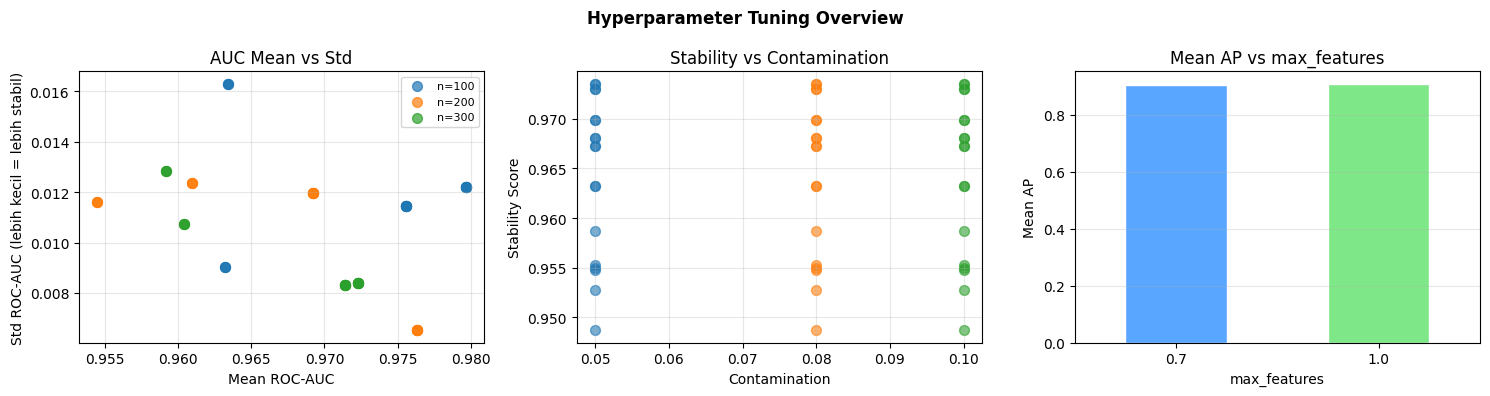

Best params : {'n_estimators': 100, 'max_samples': 256, 'max_features': 1.0, 'contamination': 0.05}
Stability   : 0.9735
AUC         : 0.9796 +/- 0.0122


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Hyperparameter Tuning Overview', fontweight='bold')

for n_est, grp in df_res.groupby('n_estimators'):
    axes[0].scatter(grp['mean_auc'], grp['std_auc'], label=f'n={n_est}', alpha=0.7, s=50)
axes[0].set_xlabel('Mean ROC-AUC')
axes[0].set_ylabel('Std ROC-AUC (lebih kecil = lebih stabil)')
axes[0].set_title('AUC Mean vs Std'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for cont, grp in df_res.groupby('contamination'):
    axes[1].scatter([cont]*len(grp), grp['stability'], alpha=0.6, s=50)
axes[1].set_xlabel('Contamination'); axes[1].set_ylabel('Stability Score')
axes[1].set_title('Stability vs Contamination'); axes[1].grid(alpha=0.3)

df_res.groupby('max_features')['mean_ap'].mean().plot(
    kind='bar', ax=axes[2], color=['#58A6FF','#7EE787'], edgecolor='white')
axes[2].set_title('Mean AP vs max_features')
axes[2].set_ylabel('Mean AP')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

best_params = df_res.iloc[0][['n_estimators','max_samples','max_features','contamination']].to_dict()
best_params['n_estimators'] = int(best_params['n_estimators'])
if isinstance(best_params['max_samples'], float) and best_params['max_samples'] == int(best_params['max_samples']):
    best_params['max_samples'] = int(best_params['max_samples'])
print('Best params :', best_params)
print(f"Stability   : {df_res.iloc[0]['stability']:.4f}")
print(f"AUC         : {df_res.iloc[0]['mean_auc']:.4f} +/- {df_res.iloc[0]['std_auc']:.4f}")

## 5. ***Training Model Final***

Model dilatih hanya pada **data normal training set** agar *decision boundary* tidak terkontaminasi pola anomali.

In [7]:
iso_final = IsolationForest(
    n_estimators  = best_params['n_estimators'],
    max_samples   = best_params['max_samples'],
    max_features  = best_params['max_features'],
    contamination = best_params['contamination'],
    bootstrap     = False,
    random_state  = 42,
    n_jobs        = -1
)
iso_final.fit(X_tr_normal_sc)
print('Model dilatih pada', len(X_tr_normal_sc), 'sesi normal.')

# Anomaly score pada seluruh dataset (untuk referensi)
# Konvensi: score lebih besar = lebih anomali
score_all = -iso_final.decision_function(X_all_sc)
print(f'Score normal  : mean={score_all[y_all==0].mean():.4f}  std={score_all[y_all==0].std():.4f}')
print(f'Score anomali : mean={score_all[y_all==1].mean():.4f}  std={score_all[y_all==1].std():.4f}')
print(f'Separation    : {score_all[y_all==1].mean() - score_all[y_all==0].mean():.4f} (harus positif)')

Model dilatih pada 960 sesi normal.
Score normal  : mean=-0.0882  std=0.0489
Score anomali : mean=0.0539  std=0.0399
Separation    : 0.1421 (harus positif)


## 6. **Optimasi *Threshold* berdasarkan *F1-Score* (*Validation Set*)**

Decision boundary tidak ditetapkan dari `contamination`, melainkan dari *threshold* yang memaksimalkan *F1-score* pada *validation set* berlabel. *Validation set* tidak disentuh selama *training* maupun *hyperparameter tuning*.

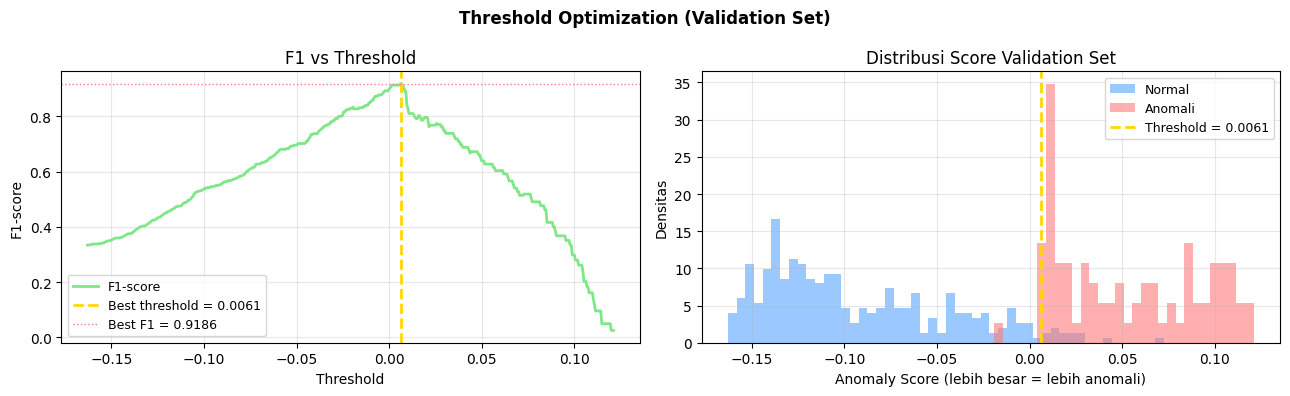

Threshold optimal : 0.0061
F1 pada val set   : 0.9186

Validation set:
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98       320
     Anomali       0.86      0.99      0.92        80

    accuracy                           0.96       400
   macro avg       0.93      0.97      0.95       400
weighted avg       0.97      0.96      0.97       400



In [8]:
score_val = -iso_final.decision_function(X_val_sc)

# Sweep threshold dari min ke max score validation
thresholds = np.linspace(score_val.min(), score_val.max(), 500)
f1_scores  = [
    f1_score(y_val, (score_val >= t).astype(int), zero_division=0)
    for t in thresholds
]
precision_scores = [
    precision_recall_curve(y_val, (score_val >= t).astype(int))[0].mean()
    if (score_val >= t).sum() > 0 else 0
    for t in thresholds
]

best_idx    = int(np.argmax(f1_scores))
best_thresh = float(thresholds[best_idx])
best_f1_val = float(f1_scores[best_idx])

# Visualisasi kurva F1 vs threshold
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Threshold Optimization (Validation Set)', fontweight='bold')

axes[0].plot(thresholds, f1_scores, color='#7EE787', lw=2, label='F1-score')
axes[0].axvline(best_thresh, color='#FFD700', lw=2, linestyle='--',
                label=f'Best threshold = {best_thresh:.4f}')
axes[0].axhline(best_f1_val, color='#FF7B7B', lw=1, linestyle=':',
                label=f'Best F1 = {best_f1_val:.4f}')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('F1-score')
axes[0].set_title('F1 vs Threshold'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].hist(score_val[y_val==0], bins=50, alpha=0.6, color='#58A6FF',
             density=True, label='Normal')
axes[1].hist(score_val[y_val==1], bins=30, alpha=0.6, color='#FF7B7B',
             density=True, label='Anomali')
axes[1].axvline(best_thresh, color='#FFD700', lw=2, linestyle='--',
                label=f'Threshold = {best_thresh:.4f}')
axes[1].set_xlabel('Anomaly Score (lebih besar = lebih anomali)')
axes[1].set_ylabel('Densitas')
axes[1].set_title('Distribusi Score Validation Set')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Threshold optimal : {best_thresh:.4f}')
print(f'F1 pada val set   : {best_f1_val:.4f}')

y_pred_val = (score_val >= best_thresh).astype(int)
print('\nValidation set:')
print(classification_report(y_val, y_pred_val, target_names=['Normal','Anomali']))

## 7. **Evaluasi Final pada *Test Set***

*Test set* belum pernah disentuh sebelumnya sehingga ini adalah evaluasi yang jujur.

=== EVALUASI FINAL — TEST SET ===
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98       320
     Anomali       0.90      0.91      0.91        80

    accuracy                           0.96       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.96      0.96      0.96       400

ROC-AUC         : 0.9819
Avg Precision   : 0.9461
F1 (anomali)    : 0.9068


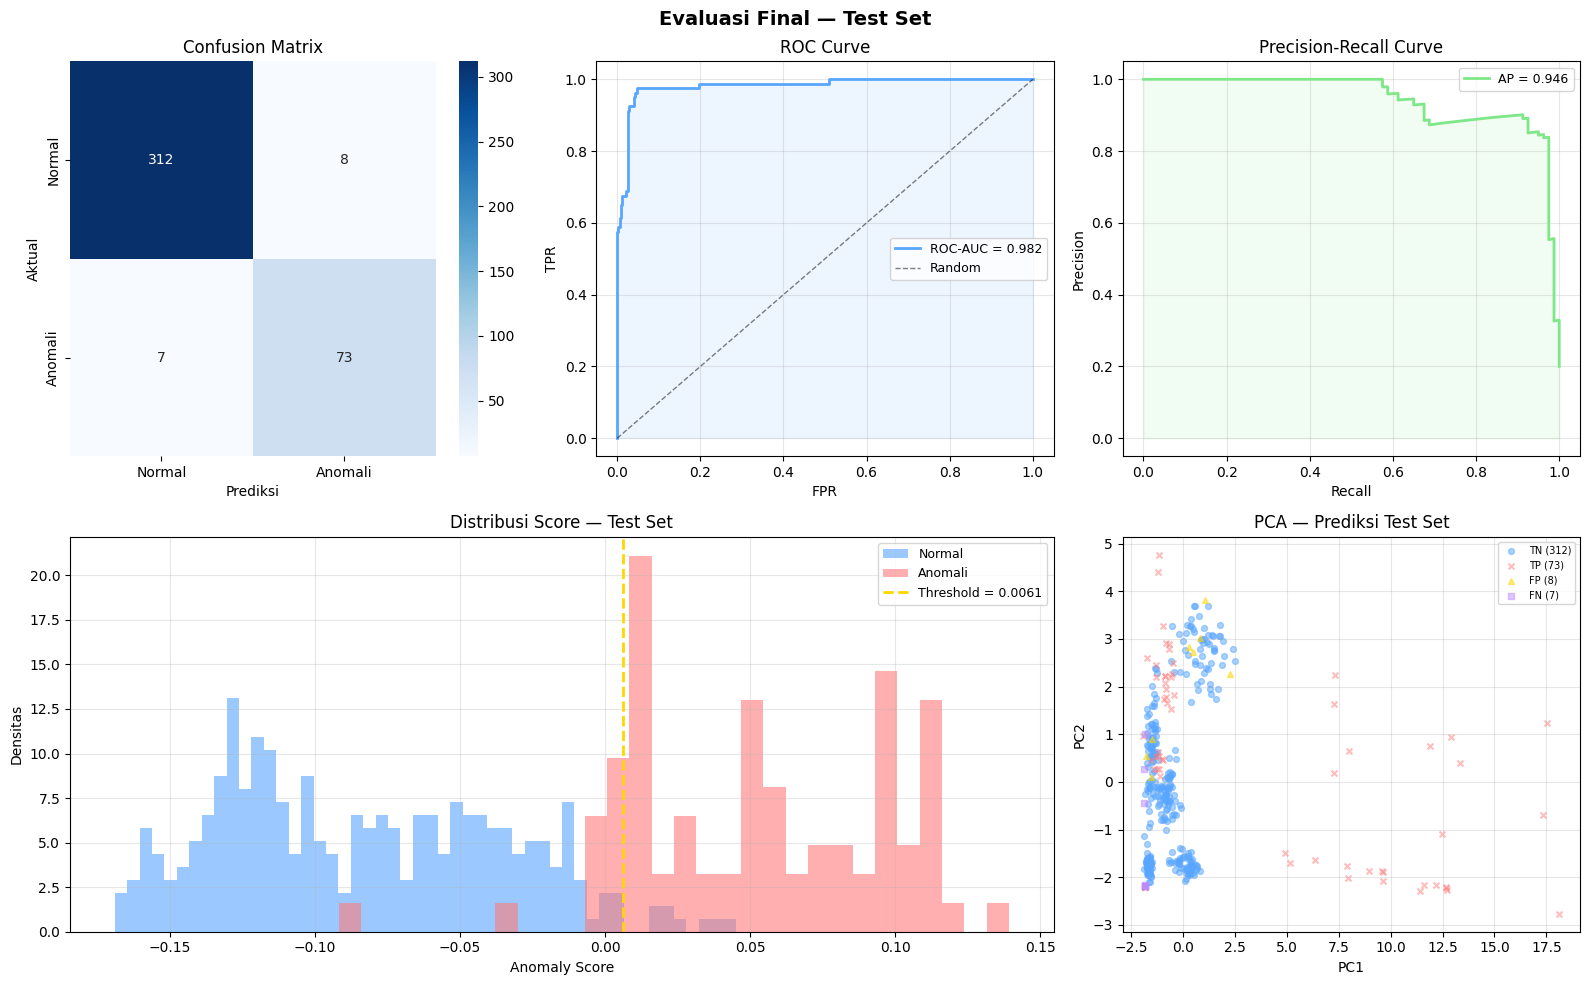

In [9]:
score_te   = -iso_final.decision_function(X_te_sc)
y_pred_te  = (score_te >= best_thresh).astype(int)

auc_te = roc_auc_score(y_te, score_te)
ap_te  = average_precision_score(y_te, score_te)
f1_te  = f1_score(y_te, y_pred_te)

print('=== EVALUASI FINAL — TEST SET ===')
print(classification_report(y_te, y_pred_te, target_names=['Normal','Anomali']))
print(f'ROC-AUC         : {auc_te:.4f}')
print(f'Avg Precision   : {ap_te:.4f}')
print(f'F1 (anomali)    : {f1_te:.4f}')

# Visualisasi lengkap
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle('Evaluasi Final — Test Set', fontsize=14, fontweight='bold')

# Confusion matrix
ax_cm = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_te, y_pred_te)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
            xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
ax_cm.set_xlabel('Prediksi'); ax_cm.set_ylabel('Aktual')
ax_cm.set_title('Confusion Matrix')

# ROC
ax_roc = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_te, score_te)
ax_roc.plot(fpr, tpr, color='#58A6FF', lw=2, label=f'ROC-AUC = {auc_te:.3f}')
ax_roc.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random')
ax_roc.fill_between(fpr, tpr, alpha=0.1, color='#58A6FF')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC Curve'); ax_roc.legend(fontsize=9); ax_roc.grid(alpha=0.3)

# Precision-Recall
ax_pr = fig.add_subplot(gs[0, 2])
prec, rec, _ = precision_recall_curve(y_te, score_te)
ax_pr.plot(rec, prec, color='#7EE787', lw=2, label=f'AP = {ap_te:.3f}')
ax_pr.fill_between(rec, prec, alpha=0.1, color='#7EE787')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve'); ax_pr.legend(fontsize=9); ax_pr.grid(alpha=0.3)

# Score distribution test set
ax_dist = fig.add_subplot(gs[1, 0:2])
ax_dist.hist(score_te[y_te==0], bins=50, alpha=0.6, color='#58A6FF',
             density=True, label='Normal')
ax_dist.hist(score_te[y_te==1], bins=30, alpha=0.6, color='#FF7B7B',
             density=True, label='Anomali')
ax_dist.axvline(best_thresh, color='#FFD700', lw=2, linestyle='--',
                label=f'Threshold = {best_thresh:.4f}')
ax_dist.set_xlabel('Anomaly Score'); ax_dist.set_ylabel('Densitas')
ax_dist.set_title('Distribusi Score — Test Set')
ax_dist.legend(fontsize=9); ax_dist.grid(alpha=0.3)

# PCA prediksi
ax_pca = fig.add_subplot(gs[1, 2])
pca2   = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_te_sc)
tp = (y_te==1)&(y_pred_te==1); tn = (y_te==0)&(y_pred_te==0)
fp = (y_te==0)&(y_pred_te==1); fn = (y_te==1)&(y_pred_te==0)
for mask, col, mk, lbl in [
    (tn,'#58A6FF','o',f'TN ({tn.sum()})'),
    (tp,'#FF7B7B','x',f'TP ({tp.sum()})'),
    (fp,'#FFD700','^',f'FP ({fp.sum()})'),
    (fn,'#BC8CFF','s',f'FN ({fn.sum()})'),
]:
    if mask.sum()>0:
        ax_pca.scatter(X_pca2[mask,0], X_pca2[mask,1],
                       c=col, marker=mk, alpha=0.5, s=18, label=lbl)
ax_pca.set_title('PCA — Prediksi Test Set')
ax_pca.set_xlabel('PC1'); ax_pca.set_ylabel('PC2')
ax_pca.legend(fontsize=7); ax_pca.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 8. **Uji *Robustness***

Tiga uji: *multi-seed*, *subsample* 70% normal, dan *Gaussian noise* 10%.
Setiap uji menggunakan *threshold* yang sama (`best_thresh`) agar evaluasi konsisten.

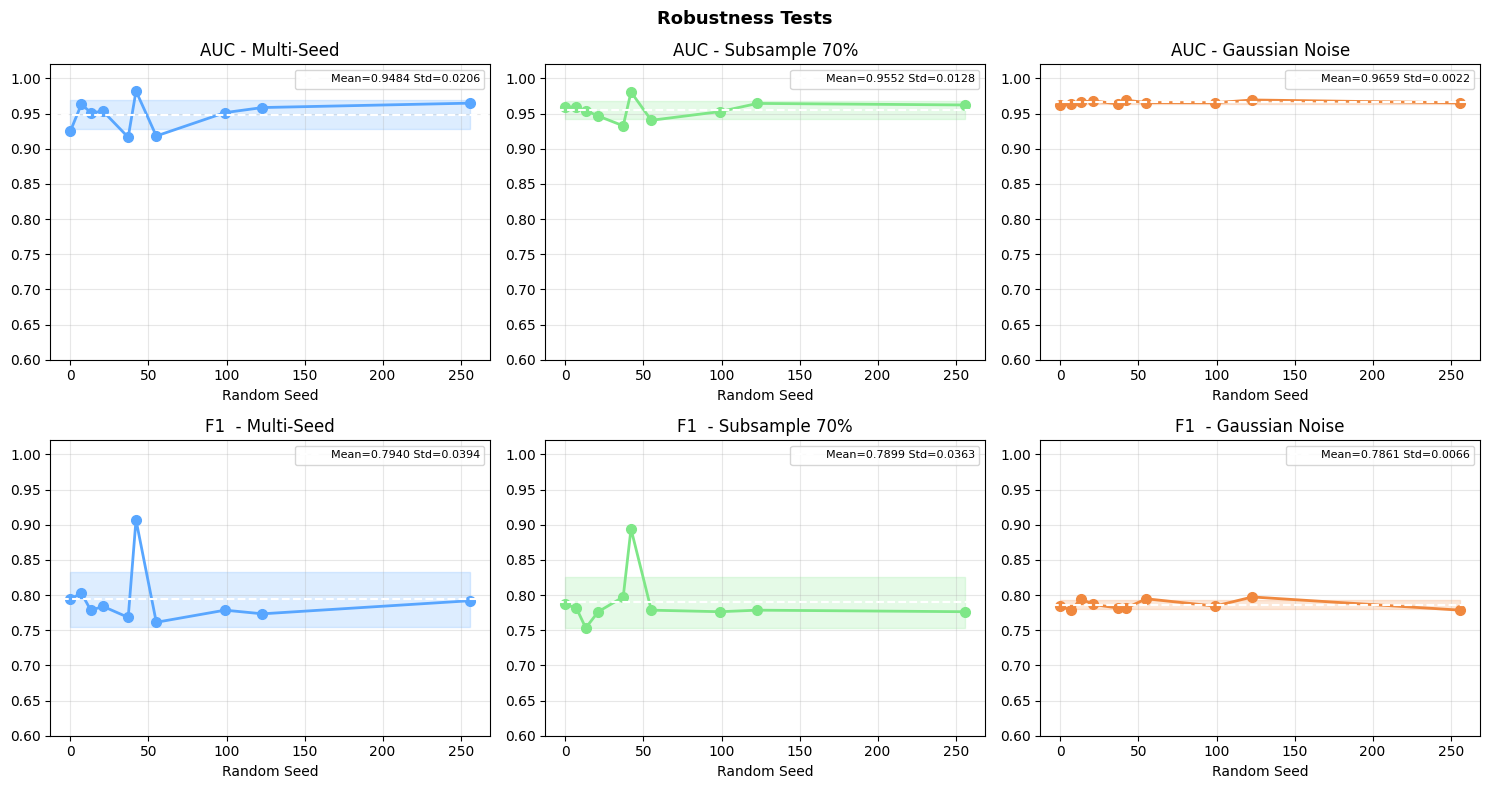

Robustness Summary (AUC)
  Multi-seed  : 0.9484 +/- 0.0206
  Subsample   : 0.9552 +/- 0.0128
  Noise       : 0.9659 +/- 0.0022

Robustness Summary (F1)
  Multi-seed  : 0.7940 +/- 0.0394
  Subsample   : 0.7899 +/- 0.0363
  Noise       : 0.7861 +/- 0.0066

Robustness check: PERLU REVIEW


In [10]:
seeds = [0, 7, 13, 21, 37, 42, 55, 99, 123, 256]
aucs_seed, aucs_sub, aucs_noise = [], [], []
f1s_seed,  f1s_sub,  f1s_noise  = [], [], []

for seed in seeds:
    rng_s = np.random.default_rng(seed)

    # 1. Multi-seed - ganti random_state saja
    iso_s = IsolationForest(**{**best_params, 'random_state': seed}, n_jobs=-1)
    iso_s.fit(X_tr_normal_sc)
    sc_s  = -iso_s.decision_function(X_te_sc)
    aucs_seed.append(roc_auc_score(y_te, sc_s))
    f1s_seed.append(f1_score(y_te, (sc_s >= best_thresh).astype(int)))

    # 2. Subsample 70% data normal
    idx_sub = rng_s.choice(len(X_tr_normal_sc),
                           size=int(0.70*len(X_tr_normal_sc)), replace=False)
    iso_sub = IsolationForest(**{**best_params, 'random_state': seed}, n_jobs=-1)
    iso_sub.fit(X_tr_normal_sc[idx_sub])
    sc_sub  = -iso_sub.decision_function(X_te_sc)
    aucs_sub.append(roc_auc_score(y_te, sc_sub))
    f1s_sub.append(f1_score(y_te, (sc_sub >= best_thresh).astype(int)))

    # 3. Gaussian noise 10% pada test set
    noise   = rng_s.normal(0, 0.10, X_te_sc.shape)
    sc_n    = -iso_final.decision_function(X_te_sc + noise)
    aucs_noise.append(roc_auc_score(y_te, sc_n))
    f1s_noise.append(f1_score(y_te, (sc_n >= best_thresh).astype(int)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Robustness Tests', fontsize=13, fontweight='bold')

configs = [
    (axes[0,0], aucs_seed,  'AUC - Multi-Seed',     '#58A6FF'),
    (axes[0,1], aucs_sub,   'AUC - Subsample 70%',  '#7EE787'),
    (axes[0,2], aucs_noise, 'AUC - Gaussian Noise', '#F0883E'),
    (axes[1,0], f1s_seed,   'F1  - Multi-Seed',     '#58A6FF'),
    (axes[1,1], f1s_sub,    'F1  - Subsample 70%',  '#7EE787'),
    (axes[1,2], f1s_noise,  'F1  - Gaussian Noise', '#F0883E'),
]
for ax, vals, title, col in configs:
    ax.plot(seeds, vals, 'o-', color=col, lw=2, markersize=7)
    ax.axhline(np.mean(vals), color='white', linestyle='--', lw=1.5,
               label=f'Mean={np.mean(vals):.4f} Std={np.std(vals):.4f}')
    ax.fill_between(seeds,
                    np.mean(vals)-np.std(vals),
                    np.mean(vals)+np.std(vals),
                    alpha=0.2, color=col)
    ax.set_title(title); ax.set_xlabel('Random Seed')
    ax.set_ylim(0.60, 1.02); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print('Robustness Summary (AUC)')
print(f'  Multi-seed  : {np.mean(aucs_seed):.4f} +/- {np.std(aucs_seed):.4f}')
print(f'  Subsample   : {np.mean(aucs_sub):.4f} +/- {np.std(aucs_sub):.4f}')
print(f'  Noise       : {np.mean(aucs_noise):.4f} +/- {np.std(aucs_noise):.4f}')
print('\nRobustness Summary (F1)')
print(f'  Multi-seed  : {np.mean(f1s_seed):.4f} +/- {np.std(f1s_seed):.4f}')
print(f'  Subsample   : {np.mean(f1s_sub):.4f} +/- {np.std(f1s_sub):.4f}')
print(f'  Noise       : {np.mean(f1s_noise):.4f} +/- {np.std(f1s_noise):.4f}')

robust_pass = (
    np.std(aucs_seed) < 0.02 and
    np.std(aucs_sub)  < 0.03 and
    np.mean(f1s_noise) > 0.70
)
print(f'\nRobustness check: {"PASS" if robust_pass else "PERLU REVIEW"}')

## 9. **Cek *Overfit / Underfit***

- AUC gap train vs test harus < 0.05
- Score variance normal harus > 0.005 (jika terlalu kecil = model tidak membedakan sesi normal)
- Separation harus **positif** (rata-rata score anomali > rata-rata score normal)

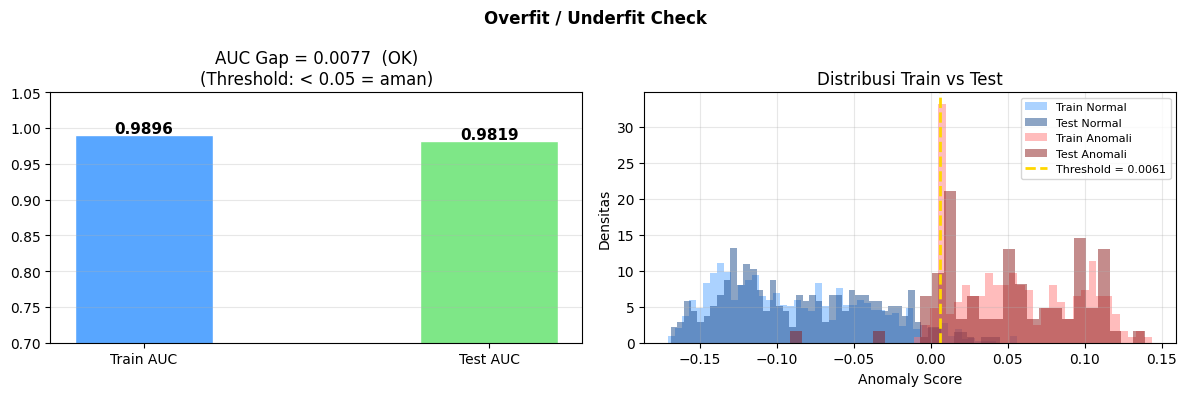

Train AUC      : 0.9896
Test  AUC      : 0.9819
AUC Gap        : 0.0077   -> TIDAK overfit
Score var (N)  : 0.00238 -> MUNGKIN underfit
Score var (A)  : 0.00151
Separation     : 0.1426   -> OK (positif)


In [11]:
score_tr_all = -iso_final.decision_function(scaler_final.transform(X_tr))
auc_tr = roc_auc_score(y_tr, score_tr_all)
gap    = abs(auc_tr - auc_te)

var_normal = score_tr_all[y_tr==0].var()
var_anom   = score_tr_all[y_tr==1].var()
sep        = score_tr_all[y_tr==1].mean() - score_tr_all[y_tr==0].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Overfit / Underfit Check', fontweight='bold')

bars = axes[0].bar(['Train AUC','Test AUC'], [auc_tr, auc_te],
                   color=['#58A6FF','#7EE787'], edgecolor='white', width=0.4)
for bar, val in zip(bars, [auc_tr, auc_te]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0.7, 1.05)
axes[0].set_title(f'AUC Gap = {gap:.4f}  ({"OK" if gap<0.05 else "OVERFIT"})\n(Threshold: < 0.05 = aman)')
axes[0].grid(alpha=0.3, axis='y')

axes[1].hist(score_tr_all[y_tr==0], bins=50, alpha=0.5, color='#58A6FF',
             density=True, label='Train Normal')
axes[1].hist(score_te[y_te==0],     bins=50, alpha=0.5, color='#1A4A8A',
             density=True, label='Test Normal')
axes[1].hist(score_tr_all[y_tr==1], bins=30, alpha=0.5, color='#FF7B7B',
             density=True, label='Train Anomali')
axes[1].hist(score_te[y_te==1],     bins=30, alpha=0.5, color='#8A1A1A',
             density=True, label='Test Anomali')
axes[1].axvline(best_thresh, color='#FFD700', lw=2, linestyle='--',
                label=f'Threshold = {best_thresh:.4f}')
axes[1].set_xlabel('Anomaly Score'); axes[1].set_ylabel('Densitas')
axes[1].set_title('Distribusi Train vs Test')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Train AUC      : {auc_tr:.4f}')
print(f'Test  AUC      : {auc_te:.4f}')
print(f'AUC Gap        : {gap:.4f}   -> {"TIDAK overfit" if gap<0.05 else "OVERFIT"}')
print(f'Score var (N)  : {var_normal:.5f} -> {"OK" if var_normal>0.005 else "MUNGKIN underfit"}')
print(f'Score var (A)  : {var_anom:.5f}')
print(f'Separation     : {sep:.4f}   -> {"OK (positif)" if sep>0 else "TERBALIK - cek scaler/threshold"}')

## 10. ***Save & Verify Model***

In [12]:
pkg = {
    # Komponen wajib — dibaca PlayerMLEngine
    'model':              iso_final,
    'scaler':             scaler_final,
    # Threshold optimal — dibaca detect_anomaly() versi baru
    'optimal_threshold':  best_thresh,
    'best_f1_val':        best_f1_val,
    # Metadata
    'best_params':        best_params,
    'auc_test':           auc_te,
    'ap_test':            ap_te,
    'f1_test':            f1_te,
    'auc_gap':            gap,
    'separation':         sep,
    'robust_pass':        robust_pass,
    'feature_names':      FEATURE_NAMES,
    'n_normal_train':     len(X_tr_normal_sc),
}

folders = Path("Files")
folders.mkdir(parents=True, exist_ok=True)
path_folder = folders / "Detect_Anomaly.pkl"

with open(path_folder, 'wb') as f:
    pickle.dump(pkg, f)

size_kb = path_folder.stat().st_size / 1024
print(f'Detect_Anomaly.pkl tersimpan ({size_kb:.1f} KB)')

Detect_Anomaly.pkl tersimpan (1417.2 KB)


In [13]:
# Verifikasi load ulang
with open(path_folder, 'rb') as f:
    loaded = pickle.load(f)

sample = scaler_final.transform(X_all[:5])
sc_v   = -loaded['model'].decision_function(sample)
pr_v   = (sc_v >= loaded['optimal_threshold']).astype(int)

print('\nVerifikasi load:')
print(f'  Scores 5 sampel  : {sc_v.round(4)}')
print(f'  Prediksi         : {pr_v}  (1=anomali)')
print(f'  Threshold        : {loaded["optimal_threshold"]:.4f}')
print(f'  AUC test         : {loaded["auc_test"]:.4f}')
print(f'  F1 test          : {loaded["f1_test"]:.4f}')
print(f'  AUC gap          : {loaded["auc_gap"]:.4f}')
print(f'  Separation       : {loaded["separation"]:.4f}')
print(f'  Robust           : {loaded["robust_pass"]}')


Verifikasi load:
  Scores 5 sampel  : [-0.1471 -0.0712 -0.0793 -0.1502 -0.1421]
  Prediksi         : [0 0 0 0 0]  (1=anomali)
  Threshold        : 0.0061
  AUC test         : 0.9819
  F1 test          : 0.9068
  AUC gap          : 0.0077
  Separation       : 0.1426
  Robust           : False
